<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="cognitiveclass.ai logo">
</center>


# Machine Learning Foundation

## Course 4, Part c: Clustering Methods LAB


# Clustering Methods Exercises


## Introduction

This lab uses a dataset on wine quality. The data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data.csv`.

We will be using the chemical properties (i.e. everything but quality and color) to cluster the wine. Though this is unsupervised learning, there are interesting semi-supervised extensions relating clustering results onto color and quality.


In [6]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import seaborn as sns, pandas as pd, numpy as np

In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns


## Question 1

*   Import the data and examine the features.
*   Note which are continuous, categorical, and boolean.
*   How many entries are there for the two colors and range of qualities?
*   Make a histogram plot of the quality for each of the wine colors.


In [8]:
### BEGIN SOLUTION
# Import the data
data = pd.read_csv("Wine_Quality_Data.csv")

data.head(4).T

,0,1,2,3
fixed_acidity,7.4,7.8,7.8,11.2
volatile_acidity,0.7,0.88,0.76,0.28
citric_acid,0.0,0.0,0.04,0.56
residual_sugar,1.9,2.6,2.3,1.9
chlorides,0.076,0.098,0.092,0.075
free_sulfur_dioxide,11.0,25.0,15.0,17.0
total_sulfur_dioxide,34.0,67.0,54.0,60.0
density,0.9978,0.9968,0.997,0.998
pH,3.51,3.2,3.26,3.16
sulphates,0.56,0.68,0.65,0.58


In [9]:
data.shape

(6497, 13)

The data types for each entry. The implementation of K-means in Scikit-learn is designed only to work with continuous data (even though it is sometimes used with categorical or boolean types). Fortunately, all the columns we will be using (everything except quality and color) are continuous.


In [10]:
data.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                    object
dtype: object

The number of entries for each wine color.


In [11]:
data.color.value_counts()

color
white    4898
red      1599
Name: count, dtype: int64

The distribution of quality values.


In [12]:
data.quality.value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Now for the histogram.


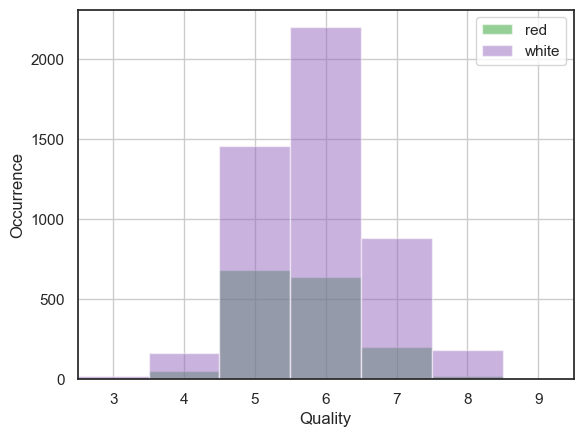

In [13]:
# seaborn styles
sns.set_context('notebook')
sns.set_style('white')

# custom colors
red = sns.color_palette()[2]
white = sns.color_palette()[4]

# set bins for histogram
bin_range = np.array([3, 4, 5, 6, 7, 8, 9])

# plot histogram of quality counts for red and white wines
ax = plt.axes()
for color, plot_color in zip(['red', 'white'], [red, white]):
    q_data = data.loc[data.color==color, 'quality']
    q_data.hist(bins=bin_range, 
                alpha=0.5, ax=ax, 
                color=plot_color, label=color)
    

ax.legend()
ax.set(xlabel='Quality', ylabel='Occurrence')

# force tick labels to be in middle of region
ax.set_xlim(3,10)
ax.set_xticks(bin_range+0.5)
ax.set_xticklabels(bin_range);
ax.grid('off')
### END SOLUTION

下面分块解释这段代码在做什么：

1. **设置 Seaborn 样式**  
   ```python
   sns.set_context('notebook')
   sns.set_style('white')
   ```  
   - `set_context('notebook')`：调整图表在 notebook 环境下的字体大小、线宽等，让图表既适合屏幕显示又不显得过于拥挤。  
   - `set_style('white')`：将图表背景设置为纯白色，去掉了默认的灰色网格背景，使得图表更简洁。

2. **自定义颜色**  
   ```python
   red   = sns.color_palette()[2]
   white = sns.color_palette()[4]
   ```  
   - `sns.color_palette()` 会返回当前调色板（默认为“deep”）的一系列颜色。  
   - 这里分别取调色板中的第 3 和第 5 种颜色赋给 `red` 和 `white`，后面用作两种直方图的填充色。

3. **设置直方图的分箱**  
   ```python
   bin_range = np.array([3, 4, 5, 6, 7, 8, 9])
   ```  
   - 定义一个分箱边界数组。这样直方图会统计质量值在 `[3,4)`、`[4,5)` … `[8,9)` 这几段区间内的样本数。

4. **创建坐标轴并绘制两条叠加直方图**  
   ```python
   ax = plt.axes()
   for color, plot_color in zip(['red', 'white'], [red, white]):
       q_data = data.loc[data.color==color, 'quality']
       q_data.hist(bins=bin_range,
                   alpha=0.5, ax=ax,
                   color=plot_color, label=color)
   ```  
   - `plt.axes()`：新建一个 `Axes` 对象，后面所有绘图命令都会往这个坐标轴上画。  
   - `for color, plot_color in zip(...):`：分别处理红酒（`color=='red'`）和白酒（`color=='white'`）。  
   - `data.loc[data.color==color, 'quality']`：从 `data` DataFrame 中，筛选出对应酒色的所有 `quality` 列数据。  
   - `q_data.hist(...)`：绘制直方图，参数说明：  
     - `bins=bin_range`：使用前面定义的分箱。  
     - `alpha=0.5`：半透明，方便两种酒色的直方图叠加时都看得清。  
     - `ax=ax`：将结果画到同一个坐标轴上。  
     - `color=plot_color`：指定填充色。  
     - `label=color`：图例标签，分别为 `"red"`、`"white"`。

5. **添加图例和坐标轴标签**  
   ```python
   ax.legend()
   ax.set(xlabel='Quality', ylabel='Occurrence')
   ```  
   - `ax.legend()`：根据前面每次 `hist(..., label=...)` 自动生成图例。  
   - `ax.set(...)`：批量设置 `xlabel` 和 `ylabel`，分别标明横轴为“Quality”（质量分），纵轴为“Occurrence”（出现次数）。

6. **调整刻度和网格**  
   ```python
   # 强制把刻度标签放到每个区间中间
   ax.set_xlim(3,10)
   ax.set_xticks(bin_range + 0.5)
   ax.set_xticklabels(bin_range)
   ax.grid('off')
   ```  
   - `set_xlim(3,10)`：将横轴限制在 `[3,10]`，保证所有分箱都在可视范围内。  
   - `set_xticks(bin_range + 0.5)`：把刻度线放在每个区间中点处，例如 `3.5, 4.5, …, 8.5`。  
   - `set_xticklabels(bin_range)`：把这些刻度线标记为整数 `3, 4, …, 9`，更直观地对应“质量分”标签。  
   - `ax.grid('off')`：关闭背景网格线，保持画面简洁。

---

**总体效果**：在同一张图上叠加展示红酒和白酒在不同质量分区间（3–9 分）的出现频率，用半透明不同颜色直方图直观对比两者的质量分分布差异。

## Question 2

*   Examine the correlation and skew of the relevant variables--everything except color and quality (without dropping these columns from our data).
*   Perform any appropriate feature transformations and/or scaling.
*   Examine the pairwise distribution of the variables with pairplots to verify scaling and normalization efforts.


In [14]:
### BEGIN SOLUTION
float_columns = [x for x in data.columns if x not in ['color', 'quality']]

# The correlation matrix
corr_mat = data[float_columns].corr()

# Strip out the diagonal values for the next step
for x in range(len(float_columns)):
    corr_mat.iloc[x,x] = 0.0
    
corr_mat

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,0.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile_acidity,0.219008,0.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric_acid,0.324436,-0.377981,0.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual_sugar,-0.111981,-0.196011,0.142451,0.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,0.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free_sulfur_dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,0.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total_sulfur_dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,0.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,0.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,0.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,0.000000,-0.003029


In [15]:
# Pairwise maximal correlations
corr_mat.abs().idxmax()

fixed_acidity                        density
volatile_acidity        total_sulfur_dioxide
citric_acid                 volatile_acidity
residual_sugar                       density
chlorides                          sulphates
free_sulfur_dioxide     total_sulfur_dioxide
total_sulfur_dioxide     free_sulfur_dioxide
density                              alcohol
pH                               citric_acid
sulphates                          chlorides
alcohol                              density
dtype: object

And an examination of the skew values in anticipation of transformations.


In [16]:
skew_columns = (data[float_columns]
                .skew()
                .sort_values(ascending=False))

skew_columns = skew_columns.loc[skew_columns > 0.75]
skew_columns

chlorides              5.399828
sulphates              1.797270
fixed_acidity          1.723290
volatile_acidity       1.495097
residual_sugar         1.435404
free_sulfur_dioxide    1.220066
dtype: float64

In [17]:
# Perform log transform on skewed columns
for col in skew_columns.index.tolist():
    data[col] = np.log1p(data[col])


Perform feature scaling.


In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
data[float_columns] = sc.fit_transform(data[float_columns])

data.head(4)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,0.229509,2.135767,-2.192833,-0.815173,0.624554,-1.193601,-1.446359,1.034993,1.813090,0.250355,-0.915464,5,red
1,0.550261,3.012817,-2.192833,-0.498175,1.281999,-0.013944,-0.862469,0.701486,-0.115073,1.059213,-0.580068,5,red
2,0.550261,2.438032,-1.917553,-0.625740,1.104012,-0.754684,-1.092486,0.768188,0.258120,0.862549,-0.580068,5,red
3,2.802728,-0.337109,1.661085,-0.815173,0.594352,-0.574982,-0.986324,1.101694,-0.363868,0.389396,-0.580068,6,red


Finally, the pairplot of the transformed and scaled features.


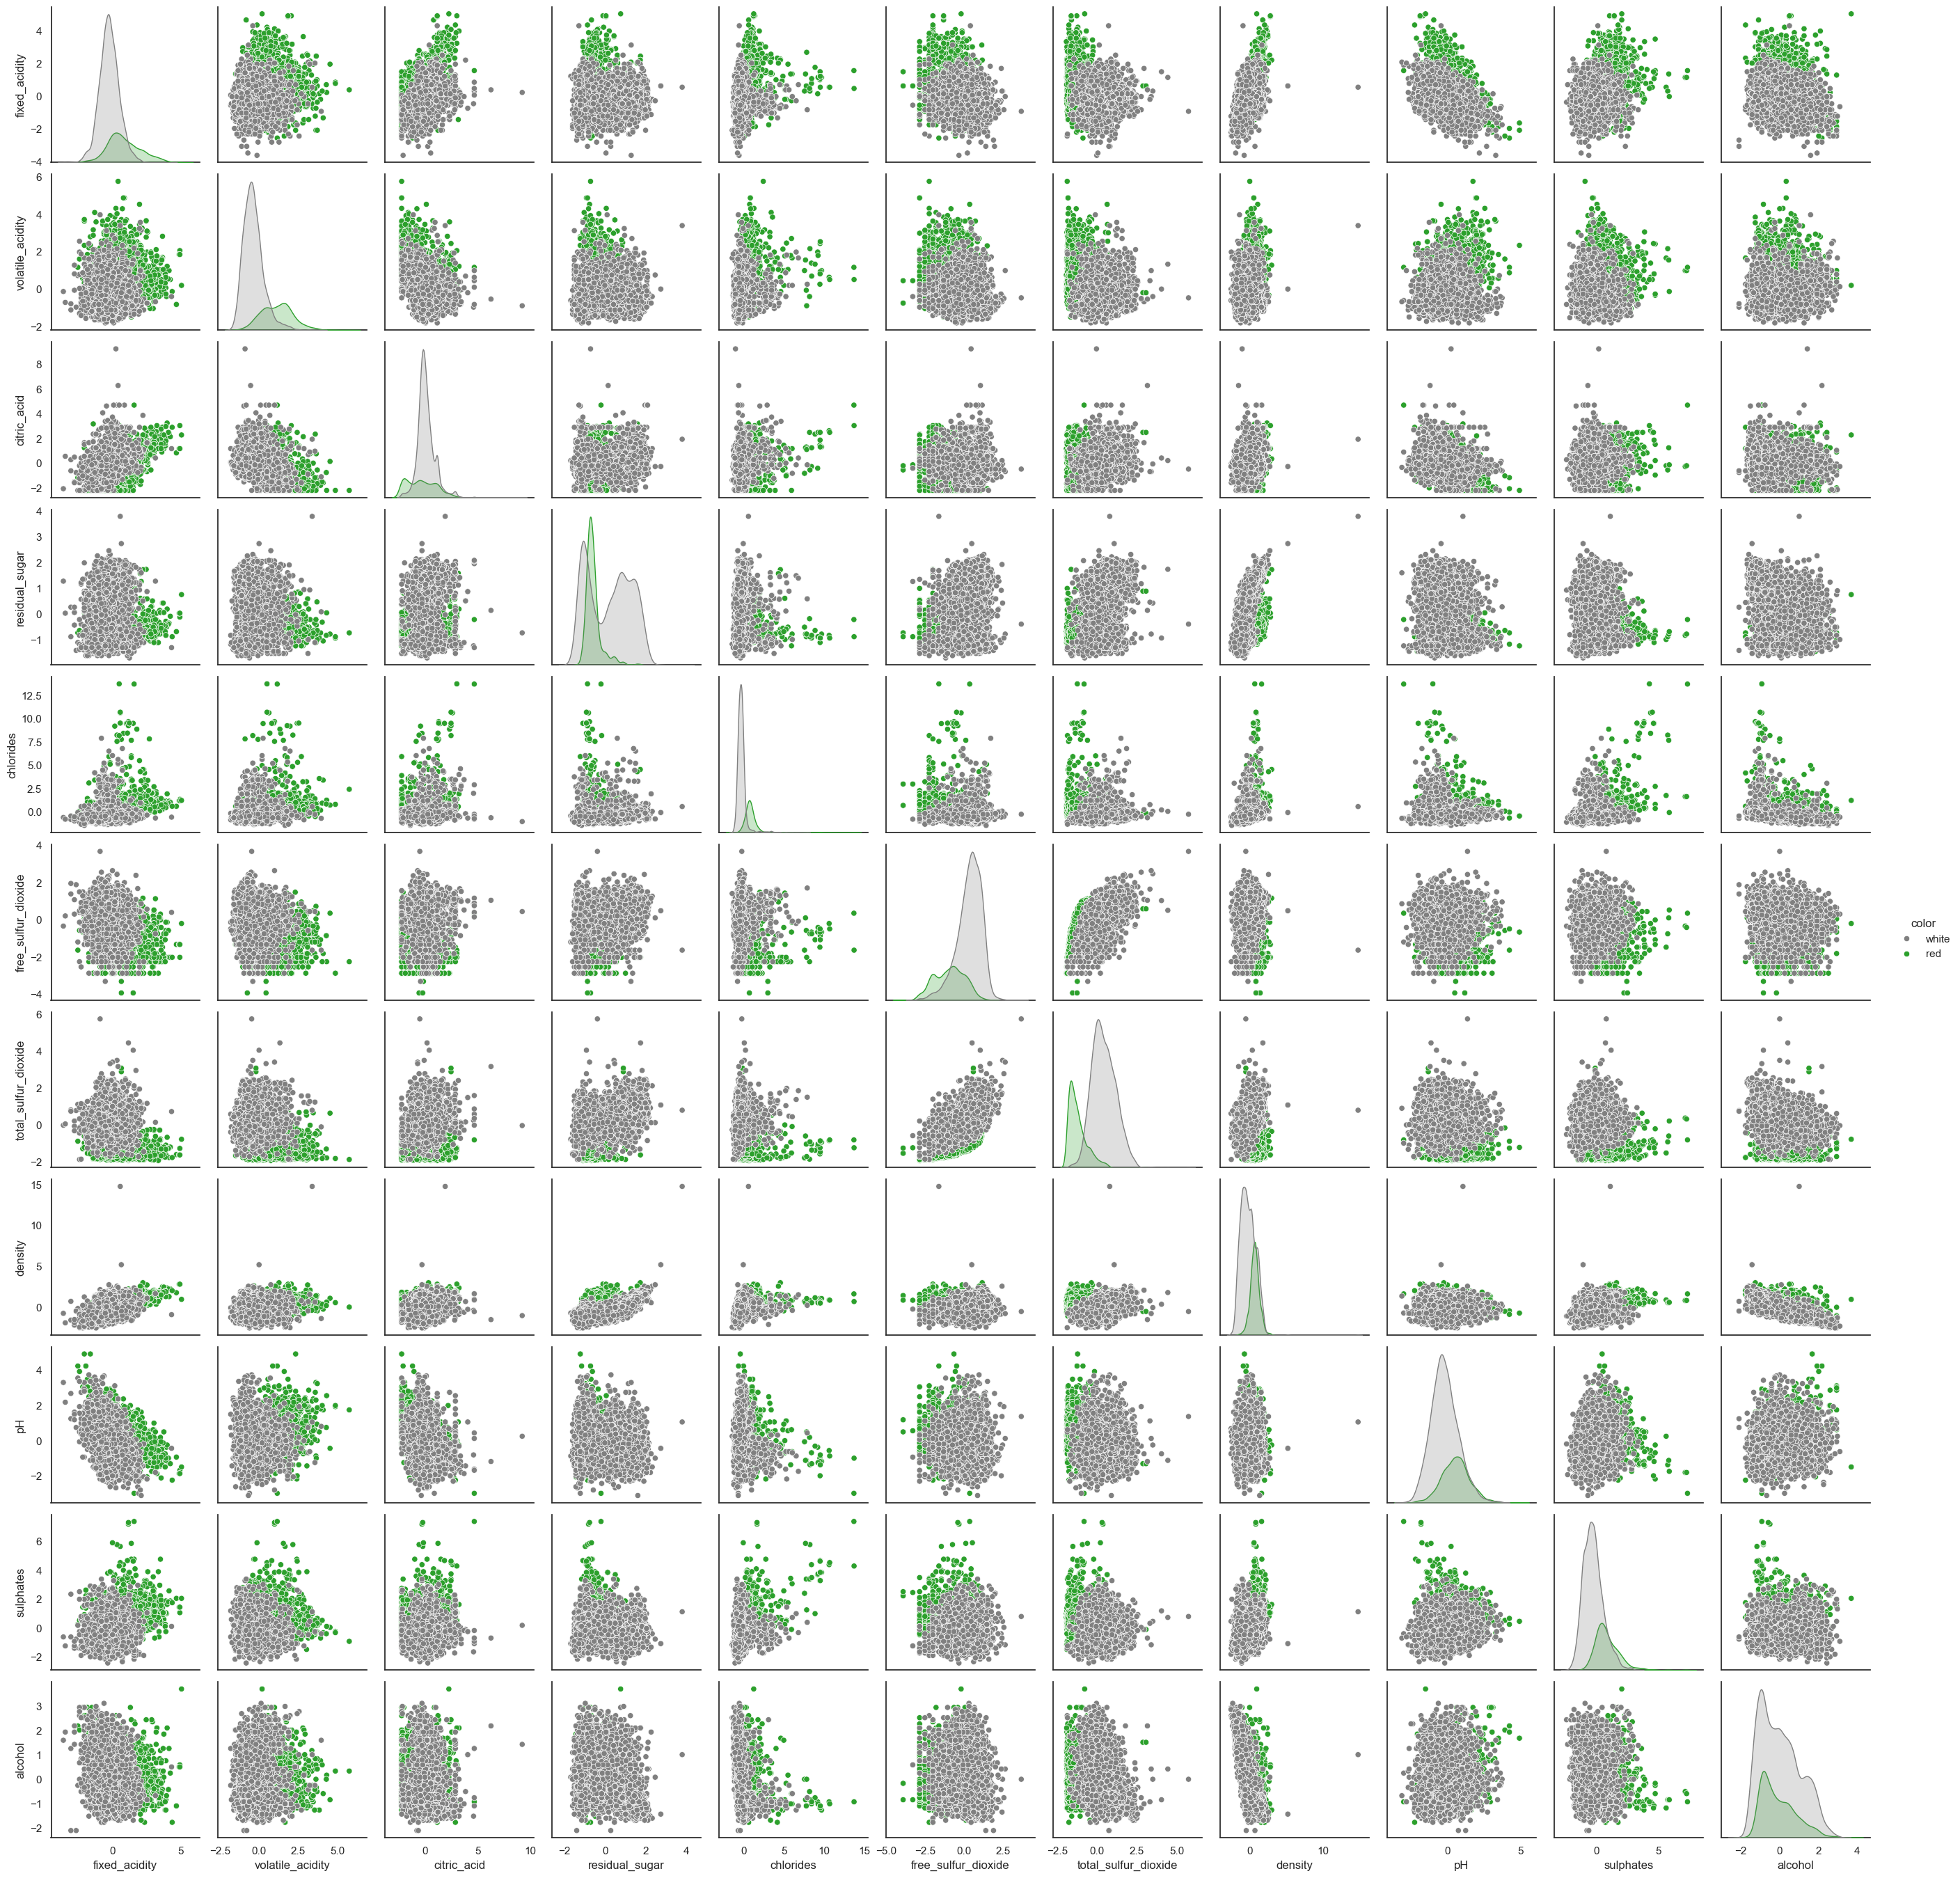

In [19]:
sns.set_context('notebook')
sns.pairplot(data[float_columns + ['color']], 
             hue='color', 
             hue_order=['white', 'red'],
             palette={'red':red, 'white':'gray'});
### END SOLUTION

这段代码主要做了以下几件事：

1. **设置绘图风格上下文**  
   ```python
   sns.set_context('notebook')
   ```  
   这行和你之前用过的 `set_context('notebook')` 一样，是告诉 Seaborn 调整文字大小、线宽、点的大小等，以适合在 Jupyter Notebook（或类似交互环境）中展示。

2. **选取数据列**  
   ```python
   data[float_columns + ['color']]
   ```  
   - `float_columns`：你事先定义好的、只含数值特征名称的列表。  
   - `+ ['color']`：再加上那一列 `color`（有 “red”/“white” 两个类别）。  
   - 结果是一个新的 DataFrame，只包含那些数值特征和一个用来分组着色的列。

3. **绘制成对图（pairplot）**  
   ```python
   sns.pairplot(...);
   ```  
   `pairplot` 会对传入的每两个数值特征组合，自动画出散点图；对每个单独特征，会在对角线上画出分布（默认为直方图）。它一眼就能帮你看出特征之间的相关性和各自的分布情况。

4. **按“color”着色**  
   ```python
   hue='color'
   ```  
   告诉 `pairplot`：把不同 `color`（“white” vs. “red”）的样本用不同颜色区分开。

5. **指定类别顺序**  
   ```python
   hue_order=['white', 'red']
   ```  
   明确先画“white”（灰色），后画“red”（红色），避免图例或图层顺序颠倒。

6. **自定义调色板**  
   ```python
   palette={'red': red, 'white': 'gray'}
   ```  
   - `red`：你之前从默认调色板里取出的第三号颜色（一个深红）。  
   - `'gray'`：直接用灰色表示白酒。  
   这样既保证了视觉一致性，也让两组易于区分。

7. **结尾的分号**  
   在 Jupyter Notebook 中加分号只是为了“抑制”输出最后一个对象（返回的 `PairGrid`），让画面更干净，不影响图形的生成。

---

**最终效果**：你会得到一个网格，每个网格单元都是两个特征的散点图（或单变量的直方图），并按照酒的颜色分成灰色和红色两组，直观展示各数值特征之间的相互关系及分布差异。

## Question 3

*   Fit a K-means clustering model with two clusters.
*   Examine the clusters by counting the number of red and white wines in each cluster.


In [20]:
from sklearn.cluster import KMeans
### BEGIN SOLUTION
km = KMeans(n_clusters=2, random_state=42)
km = km.fit(data[float_columns])

data['kmeans'] = km.predict(data[float_columns])

In [21]:
(data[['color','kmeans']]
 .groupby(['kmeans','color'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))
### END SOLUTION

number
kmeans color        
0      red      1576
       white      87
1      red        23
       white    4811

## Question 4

*   Now fit K-Means models with cluster values ranging from 1 to 20.
*   For each model, store the number of clusters and the inertia value.
*   Plot cluster number vs inertia. Does there appear to be an ideal cluster number?


In [22]:
### BEGIN SOLUTION
# Create and fit a range of models
km_list = list()

for clust in range(1,21):
    km = KMeans(n_clusters=clust, random_state=42)
    km = km.fit(data[float_columns])
    
    km_list.append(pd.Series({'clusters': clust, 
                              'inertia': km.inertia_,
                              'model': km}))

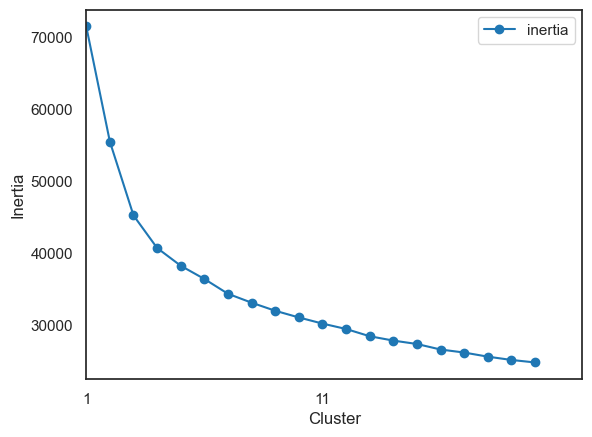

In [23]:
plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters','inertia']]
             .set_index('clusters'))

ax = plot_data.plot(marker='o',ls='-')
ax.set_xticks(range(0,21,2))
ax.set_xlim(0,21)
ax.set(xlabel='Cluster', ylabel='Inertia');
### END SOLUTION

## Question 5

*   Fit an agglomerative clustering model with two clusters.
*   Compare the results to those obtained by K-means with regards to wine color by reporting the number of red and white observations in each cluster for both K-means and agglomerative clustering.
*   Visualize the dendrogram produced by agglomerative clustering. *Hint:* SciPy has a module called [`cluster.hierarchy`](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01#module-scipy.cluster.hierarchy) that contains the `linkage` and `dendrogram` functions required to create the linkage map and plot the resulting dendrogram.


In [24]:
from sklearn.cluster import AgglomerativeClustering
### BEGIN SOLUTION
ag = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_full_tree=True)
ag = ag.fit(data[float_columns])
data['agglom'] = ag.fit_predict(data[float_columns])

Note that cluster assignment is arbitrary, the respective primary cluster numbers for red and white may not be identical to the ones below and also may not be the same for both K-means and agglomerative clustering.


In [25]:
# First, for Agglomerative Clustering:
(data[['color','agglom','kmeans']]
 .groupby(['color','agglom'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))

number
color agglom        
red   0           31
      1         1568
white 0         4755
      1          143

In [26]:
# Comparing with KMeans results:
(data[['color','agglom','kmeans']]
 .groupby(['color','kmeans'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))

number
color kmeans        
red   0         1576
      1           23
white 0           87
      1         4811

In [27]:
# Comparing results:
(data[['color','agglom','kmeans']]
 .groupby(['color','agglom','kmeans'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))

number
color agglom kmeans        
red   0      0           13
             1           18
      1      0         1563
             1            5
white 0      0           38
             1         4717
      1      0           49
             1           94

Though the cluster numbers are not identical, the clusters are very consistent within a single wine variety (red or white).

And here is a plot of the dendrogram created from agglomerative clustering.


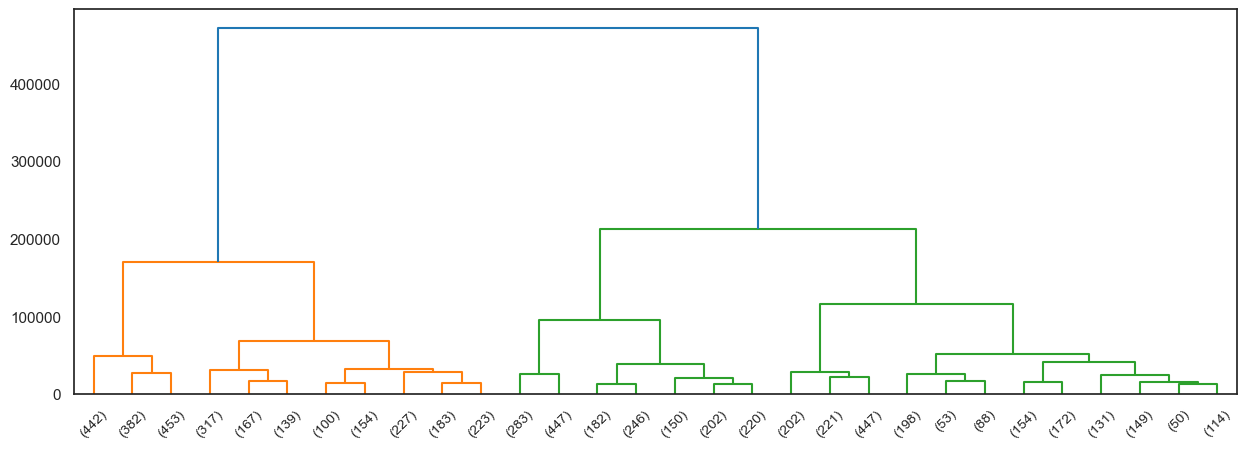

In [28]:
# First, we import the cluster hierarchy module from SciPy (described above) to obtain the linkage and dendrogram functions.
from scipy.cluster import hierarchy

Z = hierarchy.linkage(ag.children_, method='ward')

fig, ax = plt.subplots(figsize=(15,5))


den = hierarchy.dendrogram(Z, orientation='top', 
                           p=30, truncate_mode='lastp',
                           show_leaf_counts=True, ax=ax)
### END SOLUTION

## Question 6

In this question, we are going to explore clustering as a form of feature engineering.

*   Create a **binary** target variable `y`, denoting if the quality is greater than 7 or not.
*   Create a variable called `X_with_kmeans` from `data`, by dropping the columns "quality", "color" and "agglom" from the dataset. Create `X_without_kmeans` from that by dropping "kmeans".
*   For both datasets, using **[StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01)** with 10 splits, fit 10 Random Forest Classifiers and find the mean of the ROC-AUC scores from these 10 classifiers.
*   Compare the average roc-auc scores for both models, the one using the KMeans cluster as a feature and the one that doesn't use it.


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

### BEGIN SOLUTION
y = (data['quality'] > 7).astype(int)
X_with_kmeans = data.drop(['agglom', 'color', 'quality'], axis=1)
X_without_kmeans = X_with_kmeans.drop('kmeans', axis=1)
sss = StratifiedShuffleSplit(n_splits=10, random_state=6532)

def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predicted = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
    return np.mean(roc_auc_list)
# return classification_report(y_test, y_predicted)

estimator = RandomForestClassifier()
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_kmeans, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_kmeans, y)
print("Without kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))

Without kmeans cluster as input to Random Forest, roc-auc is "0.9141785714285714"
Using kmeans cluster as input to Random Forest, roc-auc is "0.9034246031746032"


下面逐步拆解这段代码在做什么：  

1. **引入所需包**  
   ```python
   from sklearn.ensemble import RandomForestClassifier
   from sklearn.metrics import classification_report, roc_auc_score
   from sklearn.model_selection import StratifiedShuffleSplit
   ```  
   - `RandomForestClassifier`：用来构建随机森林分类器。  
   - `classification_report`、`roc_auc_score`：分别用于生成分类指标报告和计算 ROC AUC 分数。  
   - `StratifiedShuffleSplit`：做分层（保证正负样本比例一致）的随机打乱划分，多次重复划分用于评估稳定性。

2. **构造二分类标签**  
   ```python
   y = (data['quality'] > 7).astype(int)
   ```  
   - 原始 `quality` 是一个多值评分。这里把分数大于 7 的样本视为“好酒”（标记为 1），其余都视为 0，得到一个二元标签 `y`。

3. **准备特征矩阵**  
   ```python
   X_with_kmeans    = data.drop(['agglom', 'color', 'quality'], axis=1)
   X_without_kmeans = X_with_kmeans.drop('kmeans', axis=1)
   ```  
   - `X_with_kmeans`：把与模型无关或不希望直接用到的列（`agglom`、`color`、原始 `quality`）都去掉，保留剩下的数值特征，其中包括一列 `kmeans`（之前做过聚类的簇标签）。  
   - `X_without_kmeans`：在上述基础上，再去掉那列 `kmeans`，用于对比“有/无聚类簇标签”这两种输入对模型性能的影响。

4. **定义分层打乱划分器**  
   ```python
   sss = StratifiedShuffleSplit(n_splits=10, random_state=6532)
   ```  
   - 将数据随机分成 10 组训练/测试集，每次划分都保证正负样本比例和原始标签分布相同。  
   - `random_state` 固定随机种子，保证结果可重复。

5. **封装十次划分后求平均 ROC AUC 的函数**  
   ```python
   def get_avg_roc_10splits(estimator, X, y):
       roc_auc_list = []
       for train_index, test_index in sss.split(X, y):
           X_train, X_test = X.iloc[train_index], X.iloc[test_index]
           y_train, y_test = y.iloc[train_index], y.iloc[test_index]
           estimator.fit(X_train, y_train)
           y_predicted = estimator.predict(X_test)
           y_scored    = estimator.predict_proba(X_test)[:, 1]
           roc_auc_list.append(roc_auc_score(y_test, y_scored))
       return np.mean(roc_auc_list)
   ```  
   - 对于每一次划分：  
     1. 根据索引提取训练集和测试集；  
     2. 用训练集 `fit` 随机森林；  
     3. `predict_proba` 得到测试集上预测为“好酒”（类别 1）的概率得分；  
     4. 用 `roc_auc_score` 计算该次的 AUC；  
   - 最后返回 10 次划分所得 AUC 的平均值，作为模型稳定性和整体性能的度量。

6. **实验并比较两种特征集**  
   ```python
   estimator = RandomForestClassifier()
   roc_with_kmeans    = get_avg_roc_10splits(estimator, X_with_kmeans, y)
   roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_kmeans, y)
   ```  
   - `roc_with_kmeans`：模型输入包含 `kmeans` 簇标签时的平均 ROC AUC。  
   - `roc_without_kmeans`：不含 `kmeans` 时的平均 ROC AUC。

7. **打印结果**  
   ```python
   print("Without kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
   print("Using kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))
   ```  
   - 将两种场景下的性能对比打印出来，方便判断“聚类簇标签”是否能为随机森林分类器带来额外的区分能力。

---

**总结**：  
- 这是一个典型的“特征工程对比实验”流程：先构造二元标签，然后分别使用包含与不包含某个新增特征（`kmeans` 聚类标签）两组特征，运用分层重复拆分策略评估模型，并对比平均 ROC AUC，以判断该特征是否能提升分类性能。

Let's now explore if the number of clusters have an effect in this improvement.

*   Create the basis training set from `data` by restricting to float_columns.
*   For $n = 1, \ldots, 20$, fit a KMeans algorithim with $n$ clusters. **[One-hot encode]()** it and add it to the **basis** training set. Don't add it to the previous iteration.
*   Fit 10 **Logistic Regression** models and compute the average roc-auc-score.
*   Plot the average roc-auc scores.


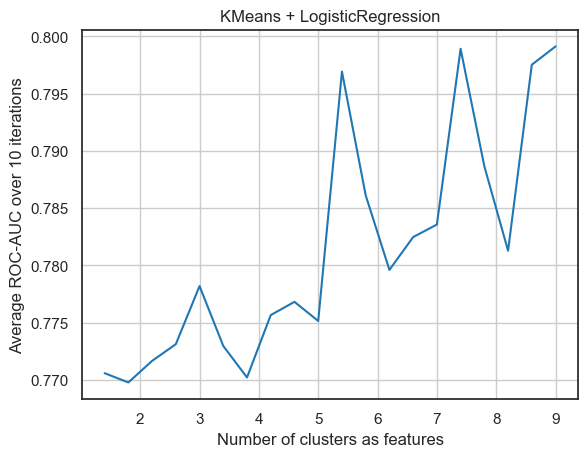

In [31]:
from sklearn.linear_model import LogisticRegression

X_basis = data[float_columns]
sss = StratifiedShuffleSplit(n_splits=10, random_state=6532)

def create_kmeans_columns(n):
    km = KMeans(n_clusters=n)
    km.fit(X_basis)
    km_col = pd.Series(km.predict(X_basis))
    km_cols = pd.get_dummies(km_col, prefix='kmeans_cluster')
    return pd.concat([X_basis, km_cols], axis=1)

estimator = LogisticRegression()
ns = range(1, 21)
roc_auc_list = [get_avg_roc_10splits(estimator, create_kmeans_columns(n), y)
                for n in ns]

ax = plt.axes()
ax.plot(ns, roc_auc_list)
ax.set(
    xticklabels= ns,
    xlabel='Number of clusters as features',
    ylabel='Average ROC-AUC over 10 iterations',
    title='KMeans + LogisticRegression'
)
ax.grid(True)
### END SOLUTION

这段代码的核心目标是：**把 KMeans 聚类标签作为哑变量（one‑hot 特征）加入到原始数值特征中，看看不同聚类数下，用 Logistic Regression 做二分类时，模型的 ROC‑AUC 怎么变化**。下面分步解释：

1. **准备基础特征**  
   ```python
   X_basis = data[float_columns]
   sss     = StratifiedShuffleSplit(n_splits=10, random_state=6532)
   ```  
   - `X_basis`：只包含原始的数值特征。  
   - `sss`：之前定义好的“分层打乱十折”划分器，用于稳定地评估模型（保证正负类比例一致）。

2. **动态生成 KMeans 哑变量特征**  
   ```python
   def create_kmeans_columns(n):
       km = KMeans(n_clusters=n)
       km.fit(X_basis)
       km_col  = pd.Series(km.predict(X_basis))
       km_cols = pd.get_dummies(km_col, prefix='kmeans_cluster')
       return pd.concat([X_basis, km_cols], axis=1)
   ```  
   - 对 `X_basis` 做 **KMeans** 聚类，指定簇数为 `n`。  
   - `km.predict(...)` 得到每个样本的簇标签（0 到 n‑1）。  
   - `pd.get_dummies(...)` 将这些标签转换成 n 列的 one‑hot 编码（每个簇一列，值为 0/1）。  
   - 最后把这 n 列哑变量拼回原始特征，得到一个新的 DataFrame，可直接用来训练模型。

3. **遍历不同的簇数，评估性能**  
   ```python
   estimator    = LogisticRegression()
   ns           = range(1, 21)
   roc_auc_list = [
       get_avg_roc_10splits(estimator, create_kmeans_columns(n), y)
       for n in ns
   ]
   ```  
   - `ns = 1,2,…,20`：测试从 1 到 20 个簇。  
   - 对每个 `n`：  
     1. 调用 `create_kmeans_columns(n)` 生成带有 `n` 个聚类哑变量的特征集；  
     2. 用之前定义的 `get_avg_roc_10splits`（对十次分层随机划分计算平均 ROC‑AUC）评估这个特征集上 Logistic Regression 的性能；  
     3. 把平均 AUC 存到 `roc_auc_list`。

4. **绘制簇数 vs. 平均 ROC‑AUC 曲线**  
   ```python
   ax = plt.axes()
   ax.plot(ns, roc_auc_list)
   ax.set(
       xticklabels=ns,
       xlabel='Number of clusters as features',
       ylabel='Average ROC-AUC over 10 iterations',
       title='KMeans + LogisticRegression'
   )
   ax.grid(True)
   ```  
   - `ax.plot(ns, roc_auc_list)`：横轴为 “簇数”，纵轴为 “对应平均 ROC‑AUC”。  
   - 通过这条曲线，你可以直观地看到：**随着簇数的增加，把聚类信息当作特征，是帮模型提升了性能，还是带来了噪声甚至致使性能下降？**  
   - 打开网格 `ax.grid(True)`，方便读数。

---

**总结**：  
- 利用无监督的 **KMeans 聚类**，将每个样本所属的簇转成 one‑hot 特征，与原始特征一起训练有监督的 **Logistic Regression**；  
- 在不同簇数量下，通过“重复分层随机划分 + 平均 ROC‑AUC”评估，判断“聚类特征”的最佳簇数，以及其对模型性能的影响；  
- 最终用一条简单的折线图，展示“簇数 vs. 平均 AUC”的关系，帮助你选择合适的 `n_clusters`。

这张曲线图直观地展示了把不同数量的 KMeans 聚类哑变量当作特征，加入到原始数值特征后，用 LogisticRegression 进行二分类，在 10 次分层随机拆分上平均 ROC‑AUC 的变化趋势：

- **簇数 = 1–2**  
  只有 1 或 2 个簇时，平均 AUC 在 ~0.770 左右，说明几乎没有额外信息加入，分类器表现接近基线。

- **簇数 = 3–5**  
  随着簇数增至 3、4、5，AUC 开始稳步上升，到 5 簇时跃升到 ~0.796，表明这时聚类特征对模型有明显增益。

- **簇数 = 6**  
  簇数继续增到 6 时，AUC 短暂回落到 ~0.780，可能是因为过多聚类后，哑变量噪声或样本稀疏度上升，反而削弱了模型泛化能力。

- **簇数 = 7–9**  
  当簇数增到 7、8、9，AUC 又重新上扬，并在 9 簇时达到全图最高点 ~0.799，说明适度增加聚类维度仍能提供有价值的信号，但最佳簇数需要通过这种“簇数 vs AUC”曲线来选取。

- **整体结论**  
  - **聚类特征确实能提升** LogisticRegression 的分类性能——相比仅用原始数值特征（AUC ≈0.770），最佳情况下可以提升到 ~0.80。  
  - **簇数选择很关键**：太少簇、新增信息有限；太多簇，哑变量过多又会带来噪声或过拟合。  
  - 从这条曲线来看，5 簇和 9 簇是两个明显的“峰值”，可以作为下一步交叉验证或网格搜索的候选设置。

***

### Machine Learning Foundation (C) 2020 IBM Corporation
